## 框架  
1️⃣ 載入資料、建立 quality_report 空表  
2️⃣ 核心欄位完整性檢查   
3️⃣ 數值合理性檢查   
4️⃣ 邏輯一致性檢查    
5️⃣ 模型污染風險檢查  
6️⃣ 結論


In [119]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os


### 載入資料

In [120]:
os.chdir("/Users/kaiping/Desktop/olist_project/data") 
os.getcwd()

'/Users/kaiping/Desktop/olist_project/data'

In [121]:
df_translation = pd.read_csv("raw/product_category_name_translation.csv")
df_sellers     = pd.read_csv("raw/olist_sellers_dataset.csv")
df_products    = pd.read_csv("raw/olist_products_dataset.csv")
df_orders      = pd.read_csv("raw/olist_orders_dataset.csv")
df_order_reviews  = pd.read_csv("raw/olist_order_reviews_dataset.csv")
df_order_payments = pd.read_csv("raw/olist_order_payments_dataset.csv")
df_order_items    = pd.read_csv("raw/olist_order_items_dataset.csv")
df_geolocation    = pd.read_csv("raw/olist_geolocation_dataset.csv")
df_customers      = pd.read_csv("raw/olist_customers_dataset.csv")


In [122]:
tables = {
    "translation": df_translation,
    "sellers": df_sellers,
    "products": df_products,
    "orders": df_orders,
    "order_reviews": df_order_reviews,
    "order_payments": df_order_payments,
    "order_items": df_order_items,
    "geolocation": df_geolocation,
    "customers": df_customers
}


In [123]:
quality_report = pd.DataFrame(columns=[
    "table",
    "column",
    "check_type",
    "rule",
    "issue_cnt",
    "issue_rate",
    "severity",
    "decision",
    "rationale"
])

### 核心欄位完整性檢查

In [124]:
critical_map = {
    "orders": [
        "order_id",
        "customer_id",
        "order_purchase_timestamp",
        "order_status"
    ],
    "order_items": ["order_id", "price"]
}


In [125]:
for table_name, cols in critical_map.items():
    df = tables[table_name]
    
    for col in cols:
        issue_cnt = df[col].isna().sum()
        issue_rate = issue_cnt / len(df)
        
        quality_report.loc[len(quality_report)] = [
            table_name,
            col,
            "null_check",
            "Critical field must not be NULL",
            issue_cnt,
            issue_rate,
            "critical" if issue_cnt > 0 else "none",
            "drop_rows" if issue_cnt > 0 else "keep",
            "Missing value directly affects RFM/LTV"
        ]


In [126]:
quality_report

,table,column,check_type,rule,issue_cnt,issue_rate,severity,decision,rationale
0,orders,order_id,null_check,Critical field must not be NULL,0,0.0,none,keep,Missing value directly affects RFM/LTV
1,orders,customer_id,null_check,Critical field must not be NULL,0,0.0,none,keep,Missing value directly affects RFM/LTV
2,orders,order_purchase_timestamp,null_check,Critical field must not be NULL,0,0.0,none,keep,Missing value directly affects RFM/LTV
3,orders,order_status,null_check,Critical field must not be NULL,0,0.0,none,keep,Missing value directly affects RFM/LTV
4,order_items,order_id,null_check,Critical field must not be NULL,0,0.0,none,keep,Missing value directly affects RFM/LTV
5,order_items,price,null_check,Critical field must not be NULL,0,0.0,none,keep,Missing value directly affects RFM/LTV


### 數值合理性檢查

In [127]:
df = tables["order_items"]
issue_cnt = (df["price"] < 0).sum()
issue_rate = issue_cnt / len(df)
print(f"訂單明細表price負值率:{issue_rate}%")

訂單明細表price負值率:0.0%


In [128]:
issue_cnt = (df["price"] == 0).sum()
print(f"訂單明細表等於0元率:{issue_rate}%")

訂單明細表等於0元率:0.0%


**價格分佈檢查**

In [129]:
df["price"].describe()

count    112650.000000
mean        120.653739
std         183.633928
min           0.850000
25%          39.900000
50%          74.990000
75%         134.900000
max        6735.000000
Name: price, dtype: float64

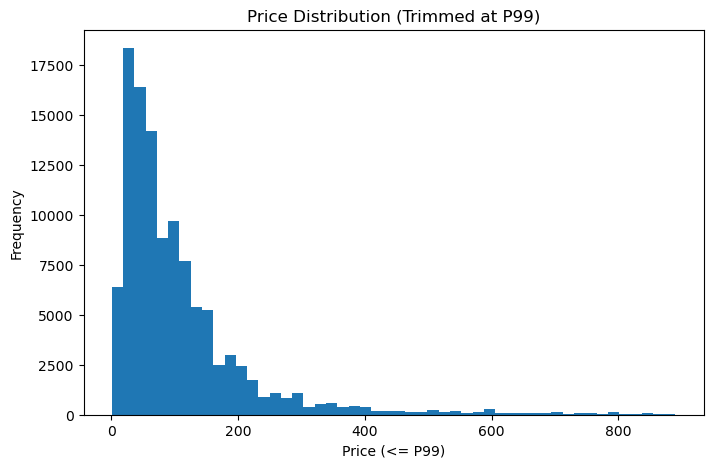

In [130]:
upper = df["price"].quantile(0.99)

plt.figure(figsize=(8,5))
plt.hist(df[df["price"] <= upper]["price"], bins=50)
plt.xlabel("Price (<= P99)")
plt.ylabel("Frequency")
plt.title("Price Distribution (Trimmed at P99)")
plt.show()


In [131]:
df["price"].quantile([0.95, 0.99, 0.999])


0.950     349.9
0.990     890.0
0.999    2110.0
Name: price, dtype: float64

**訂單明細表price分佈**
  
95%資料低於: 349元  
99%資料低於: 890元  
99.9%資料低於: 2110元  
最大值: 6735元  
99.9百分位數為 2110 元，最大值為 6735 元，極端值與主要分布未呈現明顯斷層跳躍，顯示價格分布符合電商長尾特性，未發現異常高值。

In [132]:
# Negative check
quality_report.loc[len(quality_report)] = [
    "order_items",
    "price",
    "negative_check",
    "Price must not be negative",
    0,
    0.0,
    "none",
    "keep",
    "No negative values found; no impact on LTV calculation"
]

# Zero value check
quality_report.loc[len(quality_report)] = [
    "order_items",
    "price",
    "zero_value_check",
    "Price should not be zero unless justified",
    0,
    0.0,
    "none",
    "keep",
    "No zero values found; no distortion in revenue metrics"
]

# Outlier check
quality_report.loc[len(quality_report)] = [
    "order_items",
    "price",
    "outlier_check",
    "Extreme values evaluated using P99.9 threshold",
    0,
    0.0,
    "none",
    "keep",
    "Long-tail distribution consistent with e-commerce pricing; no abnormal jump observed"
]


In [133]:
quality_report

,table,column,check_type,rule,issue_cnt,issue_rate,severity,decision,rationale
0,orders,order_id,null_check,Critical field must not be NULL,0,0.0,none,keep,Missing value directly affects RFM/LTV
1,orders,customer_id,null_check,Critical field must not be NULL,0,0.0,none,keep,Missing value directly affects RFM/LTV
2,orders,order_purchase_timestamp,null_check,Critical field must not be NULL,0,0.0,none,keep,Missing value directly affects RFM/LTV
3,orders,order_status,null_check,Critical field must not be NULL,0,0.0,none,keep,Missing value directly affects RFM/LTV
4,order_items,order_id,null_check,Critical field must not be NULL,0,0.0,none,keep,Missing value directly affects RFM/LTV
5,order_items,price,null_check,Critical field must not be NULL,0,0.0,none,keep,Missing value directly affects RFM/LTV
6,order_items,price,negative_check,Price must not be negative,0,0.0,none,keep,No negative values found; no impact on LTV cal...
7,order_items,price,zero_value_check,Price should not be zero unless justified,0,0.0,none,keep,No zero values found; no distortion in revenue...
8,order_items,price,outlier_check,Extreme values evaluated using P99.9 threshold,0,0.0,none,keep,Long-tail distribution consistent with e-comme...


### 日期欄位合理性檢查

In [134]:
df = tables["orders"]

date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")


1. purchase <= approved 訂單需要被下單才會被核准

In [135]:
mask = df["order_approved_at"] < df["order_purchase_timestamp"]
issue_cnt = mask.sum()
issue_rate = issue_cnt / len(df)

quality_report.loc[len(quality_report)] = [
    "orders",
    "order_approved_at",
    "time_order_check",
    "Approved time must be after purchase time",
    issue_cnt,
    issue_rate,
    "critical" if issue_cnt > 0 else "none",
    "investigate" if issue_cnt > 0 else "keep",
    "Invalid time order affects process logic"
]


In [136]:
quality_report

,table,column,check_type,rule,issue_cnt,issue_rate,severity,decision,rationale
0,orders,order_id,null_check,Critical field must not be NULL,0,0.0,none,keep,Missing value directly affects RFM/LTV
1,orders,customer_id,null_check,Critical field must not be NULL,0,0.0,none,keep,Missing value directly affects RFM/LTV
2,orders,order_purchase_timestamp,null_check,Critical field must not be NULL,0,0.0,none,keep,Missing value directly affects RFM/LTV
3,orders,order_status,null_check,Critical field must not be NULL,0,0.0,none,keep,Missing value directly affects RFM/LTV
4,order_items,order_id,null_check,Critical field must not be NULL,0,0.0,none,keep,Missing value directly affects RFM/LTV
5,order_items,price,null_check,Critical field must not be NULL,0,0.0,none,keep,Missing value directly affects RFM/LTV
6,order_items,price,negative_check,Price must not be negative,0,0.0,none,keep,No negative values found; no impact on LTV cal...
7,order_items,price,zero_value_check,Price should not be zero unless justified,0,0.0,none,keep,No zero values found; no distortion in revenue...
8,order_items,price,outlier_check,Extreme values evaluated using P99.9 threshold,0,0.0,none,keep,Long-tail distribution consistent with e-comme...
9,orders,order_approved_at,time_order_check,Approved time must be after purchase time,0,0.0,none,keep,Invalid time order affects process logic


2. purchase <= delivered_customer 客戶下單時間需要小於送達客戶地址時間

In [137]:
mask = df["order_delivered_customer_date"] < df["order_purchase_timestamp"]
issue_cnt = mask.sum()
issue_rate = issue_cnt / len(df)

quality_report.loc[len(quality_report)] = [
    "orders",
    "order_delivered_customer_date",
    "time_order_check",
    "Delivered date must be after purchase date",
    issue_cnt,
    issue_rate,
    "critical" if issue_cnt > 0 else "none",
    "investigate" if issue_cnt > 0 else "keep",
    "Invalid sequence distorts delivery delay"
]


In [138]:
quality_report

,table,column,check_type,rule,issue_cnt,issue_rate,severity,decision,rationale
0,orders,order_id,null_check,Critical field must not be NULL,0,0.0,none,keep,Missing value directly affects RFM/LTV
1,orders,customer_id,null_check,Critical field must not be NULL,0,0.0,none,keep,Missing value directly affects RFM/LTV
2,orders,order_purchase_timestamp,null_check,Critical field must not be NULL,0,0.0,none,keep,Missing value directly affects RFM/LTV
3,orders,order_status,null_check,Critical field must not be NULL,0,0.0,none,keep,Missing value directly affects RFM/LTV
4,order_items,order_id,null_check,Critical field must not be NULL,0,0.0,none,keep,Missing value directly affects RFM/LTV
5,order_items,price,null_check,Critical field must not be NULL,0,0.0,none,keep,Missing value directly affects RFM/LTV
6,order_items,price,negative_check,Price must not be negative,0,0.0,none,keep,No negative values found; no impact on LTV cal...
7,order_items,price,zero_value_check,Price should not be zero unless justified,0,0.0,none,keep,No zero values found; no distortion in revenue...
8,order_items,price,outlier_check,Extreme values evaluated using P99.9 threshold,0,0.0,none,keep,Long-tail distribution consistent with e-comme...
9,orders,order_approved_at,time_order_check,Approved time must be after purchase time,0,0.0,none,keep,Invalid time order affects process logic


3. carrier <= delivered_customer 商品交給物流商時間需要小於商品送到客人地址時間

In [139]:
mask = df["order_delivered_customer_date"] < df["order_delivered_carrier_date"]
issue_cnt = mask.sum()
issue_rate = issue_cnt / len(df)

quality_report.loc[len(quality_report)] = [
    "orders",
    "order_delivered_customer_date",
    "time_order_check",
    "Delivered customer date must be after carrier date",
    issue_cnt,
    issue_rate,
    "critical" if issue_cnt > 0 else "none",
    "investigate" if issue_cnt > 0 else "keep",
    "Invalid logistics sequence distorts delivery process logic"
]


In [140]:
quality_report

,table,column,check_type,rule,issue_cnt,issue_rate,severity,decision,rationale
0,orders,order_id,null_check,Critical field must not be NULL,0,0.000000,none,keep,Missing value directly affects RFM/LTV
1,orders,customer_id,null_check,Critical field must not be NULL,0,0.000000,none,keep,Missing value directly affects RFM/LTV
2,orders,order_purchase_timestamp,null_check,Critical field must not be NULL,0,0.000000,none,keep,Missing value directly affects RFM/LTV
3,orders,order_status,null_check,Critical field must not be NULL,0,0.000000,none,keep,Missing value directly affects RFM/LTV
4,order_items,order_id,null_check,Critical field must not be NULL,0,0.000000,none,keep,Missing value directly affects RFM/LTV
5,order_items,price,null_check,Critical field must not be NULL,0,0.000000,none,keep,Missing value directly affects RFM/LTV
6,order_items,price,negative_check,Price must not be negative,0,0.000000,none,keep,No negative values found; no impact on LTV cal...
7,order_items,price,zero_value_check,Price should not be zero unless justified,0,0.000000,none,keep,No zero values found; no distortion in revenue...
8,order_items,price,outlier_check,Extreme values evaluated using P99.9 threshold,0,0.000000,none,keep,Long-tail distribution consistent with e-comme...
9,orders,order_approved_at,time_order_check,Approved time must be after purchase time,0,0.000000,none,keep,Invalid time order affects process logic


4. estimated_delivery_date ≥ purchase 預估送達時間需要大於客戶下單時間

In [143]:
mask = df["order_estimated_delivery_date"] < df["order_purchase_timestamp"]
issue_cnt = mask.sum()
issue_rate = issue_cnt / len(df)

quality_report.loc[len(quality_report)] = [
    "orders",
    "order_estimated_delivery_date",
    "time_order_check",
    "Estimated delivery date should be after purchase date",
    issue_cnt,
    issue_rate,
    "major" if issue_cnt > 0 else "none",
    "investigate" if issue_cnt > 0 else "keep",
    "Unrealistic estimated date may affect delivery delay feature"
]


In [144]:
quality_report

,table,column,check_type,rule,issue_cnt,issue_rate,severity,decision,rationale
0,orders,order_id,null_check,Critical field must not be NULL,0,0.000000,none,keep,Missing value directly affects RFM/LTV
1,orders,customer_id,null_check,Critical field must not be NULL,0,0.000000,none,keep,Missing value directly affects RFM/LTV
2,orders,order_purchase_timestamp,null_check,Critical field must not be NULL,0,0.000000,none,keep,Missing value directly affects RFM/LTV
3,orders,order_status,null_check,Critical field must not be NULL,0,0.000000,none,keep,Missing value directly affects RFM/LTV
4,order_items,order_id,null_check,Critical field must not be NULL,0,0.000000,none,keep,Missing value directly affects RFM/LTV
5,order_items,price,null_check,Critical field must not be NULL,0,0.000000,none,keep,Missing value directly affects RFM/LTV
6,order_items,price,negative_check,Price must not be negative,0,0.000000,none,keep,No negative values found; no impact on LTV cal...
7,order_items,price,zero_value_check,Price should not be zero unless justified,0,0.000000,none,keep,No zero values found; no distortion in revenue...
8,order_items,price,outlier_check,Extreme values evaluated using P99.9 threshold,0,0.000000,none,keep,Long-tail distribution consistent with e-comme...
9,orders,order_approved_at,time_order_check,Approved time must be after purchase time,0,0.000000,none,keep,Invalid time order affects process logic


### 訂單狀態邏輯性檢查

In [145]:
df_orders = tables["orders"]
df_reviews = tables["order_reviews"]

1. delivered 訂單是否都有 delivered_date

In [152]:
mask = (
    (df_orders["order_status"] == "delivered") &
    (df_orders["order_delivered_customer_date"].isna())
)

issue_cnt = mask.sum()
issue_rate = issue_cnt / len(df_orders)

quality_report.loc[len(quality_report)] = [
    "orders",
    "order_delivered_customer_date",
    "status_logic_check",
    "Delivered orders must have delivered_customer_date",
    issue_cnt,
    issue_rate,
    "critical" if issue_cnt > 0 else "none",
    "investigate" if issue_cnt > 0 else "keep",
    "Missing delivered date corrupts delivery_delay and satisfaction features"
]
quality_report

,table,column,check_type,rule,issue_cnt,issue_rate,severity,decision,rationale
0,orders,order_id,null_check,Critical field must not be NULL,0,0.000000,none,keep,Missing value directly affects RFM/LTV
1,orders,customer_id,null_check,Critical field must not be NULL,0,0.000000,none,keep,Missing value directly affects RFM/LTV
2,orders,order_purchase_timestamp,null_check,Critical field must not be NULL,0,0.000000,none,keep,Missing value directly affects RFM/LTV
3,orders,order_status,null_check,Critical field must not be NULL,0,0.000000,none,keep,Missing value directly affects RFM/LTV
4,order_items,order_id,null_check,Critical field must not be NULL,0,0.000000,none,keep,Missing value directly affects RFM/LTV
5,order_items,price,null_check,Critical field must not be NULL,0,0.000000,none,keep,Missing value directly affects RFM/LTV
6,order_items,price,negative_check,Price must not be negative,0,0.000000,none,keep,No negative values found; no impact on LTV cal...
7,order_items,price,zero_value_check,Price should not be zero unless justified,0,0.000000,none,keep,No zero values found; no distortion in revenue...
8,order_items,price,outlier_check,Extreme values evaluated using P99.9 threshold,0,0.000000,none,keep,Long-tail distribution consistent with e-comme...
9,orders,order_approved_at,time_order_check,Approved time must be after purchase time,0,0.000000,none,keep,Invalid time order affects process logic


2. canceled 訂單是否沒有 delivered_date

In [153]:
mask = (
    (df_orders["order_status"] == "canceled") &
    (df_orders["order_delivered_customer_date"].notna())
)

issue_cnt = mask.sum()
issue_rate = issue_cnt / len(df_orders)

quality_report.loc[len(quality_report)] = [
    "orders",
    "order_delivered_customer_date",
    "status_logic_check",
    "Canceled orders should not have delivered_customer_date",
    issue_cnt,
    issue_rate,
    "major" if issue_cnt > 0 else "none",
    "investigate" if issue_cnt > 0 else "keep",
    "Inconsistent status may distort delivery performance metrics"
]

quality_report


,table,column,check_type,rule,issue_cnt,issue_rate,severity,decision,rationale
0,orders,order_id,null_check,Critical field must not be NULL,0,0.000000,none,keep,Missing value directly affects RFM/LTV
1,orders,customer_id,null_check,Critical field must not be NULL,0,0.000000,none,keep,Missing value directly affects RFM/LTV
2,orders,order_purchase_timestamp,null_check,Critical field must not be NULL,0,0.000000,none,keep,Missing value directly affects RFM/LTV
3,orders,order_status,null_check,Critical field must not be NULL,0,0.000000,none,keep,Missing value directly affects RFM/LTV
4,order_items,order_id,null_check,Critical field must not be NULL,0,0.000000,none,keep,Missing value directly affects RFM/LTV
5,order_items,price,null_check,Critical field must not be NULL,0,0.000000,none,keep,Missing value directly affects RFM/LTV
6,order_items,price,negative_check,Price must not be negative,0,0.000000,none,keep,No negative values found; no impact on LTV cal...
7,order_items,price,zero_value_check,Price should not be zero unless justified,0,0.000000,none,keep,No zero values found; no distortion in revenue...
8,order_items,price,outlier_check,Extreme values evaluated using P99.9 threshold,0,0.000000,none,keep,Long-tail distribution consistent with e-comme...
9,orders,order_approved_at,time_order_check,Approved time must be after purchase time,0,0.000000,none,keep,Invalid time order affects process logic


In [157]:
quality_report

,table,column,check_type,rule,issue_cnt,issue_rate,severity,decision,rationale
0,orders,order_id,null_check,Critical field must not be NULL,0,0.000000,none,keep,Missing value directly affects RFM/LTV
1,orders,customer_id,null_check,Critical field must not be NULL,0,0.000000,none,keep,Missing value directly affects RFM/LTV
2,orders,order_purchase_timestamp,null_check,Critical field must not be NULL,0,0.000000,none,keep,Missing value directly affects RFM/LTV
3,orders,order_status,null_check,Critical field must not be NULL,0,0.000000,none,keep,Missing value directly affects RFM/LTV
4,order_items,order_id,null_check,Critical field must not be NULL,0,0.000000,none,keep,Missing value directly affects RFM/LTV
5,order_items,price,null_check,Critical field must not be NULL,0,0.000000,none,keep,Missing value directly affects RFM/LTV
6,order_items,price,negative_check,Price must not be negative,0,0.000000,none,keep,No negative values found; no impact on LTV cal...
7,order_items,price,zero_value_check,Price should not be zero unless justified,0,0.000000,none,keep,No zero values found; no distortion in revenue...
8,order_items,price,outlier_check,Extreme values evaluated using P99.9 threshold,0,0.000000,none,keep,Long-tail distribution consistent with e-comme...
9,orders,order_approved_at,time_order_check,Approved time must be after purchase time,0,0.000000,none,keep,Invalid time order affects process logic


### 檢查訂單狀態集中程度

In [162]:
counts = df_orders["order_status"].value_counts()
rates = df_orders["order_status"].value_counts(normalize=True)

status_summary = pd.DataFrame({
    "count": counts,
    "rate": rates
})

status_summary


,count,rate
order_status,,
delivered,96478,0.970203
shipped,1107,0.011132
canceled,625,0.006285
unavailable,609,0.006124
invoiced,314,0.003158
processing,301,0.003027
created,5,0.000050
approved,2,0.000020


In [163]:
quality_report.loc[len(quality_report)] = [
    "orders",
    "order_status",
    "distribution_check",
    "Check order status distribution for abnormal concentration",
    0,
    0.0,
    "none",
    "keep",
    "Delivered orders account for 97.02%, canceled/unavailable 1.24%; distribution consistent with historical e-commerce dataset"
]
quality_report

,table,column,check_type,rule,issue_cnt,issue_rate,severity,decision,rationale
0,orders,order_id,null_check,Critical field must not be NULL,0,0.000000,none,keep,Missing value directly affects RFM/LTV
1,orders,customer_id,null_check,Critical field must not be NULL,0,0.000000,none,keep,Missing value directly affects RFM/LTV
2,orders,order_purchase_timestamp,null_check,Critical field must not be NULL,0,0.000000,none,keep,Missing value directly affects RFM/LTV
3,orders,order_status,null_check,Critical field must not be NULL,0,0.000000,none,keep,Missing value directly affects RFM/LTV
4,order_items,order_id,null_check,Critical field must not be NULL,0,0.000000,none,keep,Missing value directly affects RFM/LTV
5,order_items,price,null_check,Critical field must not be NULL,0,0.000000,none,keep,Missing value directly affects RFM/LTV
6,order_items,price,negative_check,Price must not be negative,0,0.000000,none,keep,No negative values found; no impact on LTV cal...
7,order_items,price,zero_value_check,Price should not be zero unless justified,0,0.000000,none,keep,No zero values found; no distortion in revenue...
8,order_items,price,outlier_check,Extreme values evaluated using P99.9 threshold,0,0.000000,none,keep,Long-tail distribution consistent with e-comme...
9,orders,order_approved_at,time_order_check,Approved time must be after purchase time,0,0.000000,none,keep,Invalid time order affects process logic


In [166]:
os.chdir("/Users/kaiping/Desktop/olist_project/notebooks/data_understanding")

quality_report_output_path = Path("quality_report.csv")

if not quality_report_output_path.exists():
    quality_report.to_csv(quality_report_output_path, index=False, encoding="utf-8-sig")
    print(f"已儲存：{quality_report_output_path}（位於 {os.getcwd()}）")
else:
    print(f"已存在，未覆蓋：{quality_report_output_path}（位於 {os.getcwd()}）")

已儲存：quality_report.csv（位於 /Users/kaiping/Desktop/olist_project/notebooks/data_understanding）
